# PlantVillage Data Preprocessing (32x32 Grayscale Vectors)

Bu notebook, PlantVillage veri setini klasik makine öğrenmesi yöntemleri

(Logistic Regression, SVM, Random Forest vb.) için hazırlar.

Adımlar:

1. Veri seti yolunu ve temel ayarları yapmak

2. PlantVillage klasörlerini tarayıp sınıf isimlerini ve label indekslerini oluşturmak

3. Görselleri 32x32 gri tonlamalı hale getirip [0, 1] aralığına normalize etmek ve vektöre dönüştürmek

4. `X` (özellik vektörleri) ve `y` (sınıf etiketleri) listelerini oluşturmak

5. Train / Validation / Test bölme işlemini yapmak

6. (Opsiyonel) İşlenmiş veriyi `.npy` dosyalarına kaydetmek

## Cell 1 – Importlar ve temel ayarlar

In [1]:
import os
import random
from PIL import Image  # for image loading and processing
import numpy as np     # optional: for saving arrays and simple checks
import matplotlib.pyplot as plt  # optional: for visualization

# -------------------
# Configuration
# -------------------
# Root folder of your PlantVillage dataset.
# Example structure:
# DATA_ROOT/
#    Tomato___Early_blight/
#    Tomato___Late_blight/
#    Tomato___healthy/
#    ...
DATA_ROOT = "../Datasets/plantvillage/color"  # <-- CHANGE THIS TO YOUR ACTUAL PATH

# Target image size (we will use 32x32 grayscale)
IMG_SIZE = 32

# Train / validation / test split ratios
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15  # remaining will be test

Bu hücrede:

* Gerekli kütüphaneleri yüklüyoruz (`PIL` ile görsel okuma, `numpy` ile veri saklama).

* PlantVillage klasörünün yolunu (`DATA_ROOT`) ayarlıyoruz.

* Tüm imagenin `32x32` gri seviyeye dönüştürüleceğini ve train/val/test oranlarını tanımlıyoruz.

## Cell 2 – Sınıf isimlerini okuma ve mapping oluşturma

In [2]:
def get_class_names(root_dir):
    """
    Scan the root directory and return sorted class (folder) names.
    Each subfolder is assumed to represent one class.
    """
    class_names = [
        d for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ]
    class_names = sorted(class_names)
    return class_names

class_names = get_class_names(DATA_ROOT)
print("Number of classes:", len(class_names))
print("First 10 classes:", class_names[:10])

Number of classes: 38
First 10 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


Burada:

* `DATA_ROOT` altındaki **klasör isimlerini** okuyup `class_names` listesine alıyoruz.

* Her klasörü bir sınıf (hastalık türü + bitki türü) olarak kabul ediyoruz.

* Kaç sınıf olduğunu ve ilk birkaç tanesini ekrana yazdırıyoruz.

## Cell 3 – Sınıf isimlerini label indeksine çevirme

In [3]:
# Create mapping from class name to integer label index
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

print("Example mapping (class_to_idx):")
for name, idx in list(class_to_idx.items())[:10]:
    print(f"{name} -> {idx}")

Example mapping (class_to_idx):
Apple___Apple_scab -> 0
Apple___Black_rot -> 1
Apple___Cedar_apple_rust -> 2
Apple___healthy -> 3
Blueberry___healthy -> 4
Cherry_(including_sour)___Powdery_mildew -> 5
Cherry_(including_sour)___healthy -> 6
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> 7
Corn_(maize)___Common_rust_ -> 8
Corn_(maize)___Northern_Leaf_Blight -> 9


* Her sınıf ismini (klasör adını) bir **tamsayı label** ile eşliyoruz (`0, 1, 2, ...`).

* Hem `class_to_idx` (isim → index) hem `idx_to_class` (index → isim) mapping'lerini oluşturuyoruz.

* Bu mapping, daha sonra `y` (etiket listesi) için kullanılacak.

## Cell 4 – Görüntüyü 32×32 gri vektöre çeviren fonksiyon

In [4]:
def load_image_as_vector(path, img_size=IMG_SIZE):
    """
    Load an image file, convert it to grayscale, resize to img_size x img_size,
    normalize pixel values to [0, 1], and flatten to a 1D list (feature vector).
    """
    with Image.open(path) as img:
        # Convert to grayscale ("L" mode)
        img = img.convert("L")
        # Resize to (img_size, img_size)
        img = img.resize((img_size, img_size))
        # Get pixel values as a flat sequence
        pixels = list(img.getdata())  # length = img_size * img_size
        # Normalize to [0, 1]
        vector = [p / 255.0 for p in pixels]
        return vector

Bu fonksiyon:

1. Dosya yolundan görseli açıyor.

2. Gri tona çeviriyor (`"L"` modu).

3. `IMG_SIZE x IMG_SIZE` boyutuna küçültüyor (bizim durumda 32x32).

4. Piksel değerlerini `[0, 255]` aralığından `[0, 1]` aralığına normalize ediyor.

5. 2D görüntüyü **flatten** edip 1D vektör haline getiriyor (örneğin 32×32 = 1024 boyutlu vektör).

Bu vektör, Logistic Regression / SVM / Random Forest modeline girecek **özellik vektörü (feature vector)** olacak.

## Cell 5 – PlantVillage klasöründen X ve y üretme

In [5]:
def load_plantvillage_from_root(root_dir, class_to_idx, max_images_per_class=None):
    """
    Load PlantVillage dataset from directory structure:
        root_dir/
            class_name_1/
                *.jpg, *.png, ...
            class_name_2/
                ...
            ...
    Args:
        root_dir: root directory of PlantVillage dataset
        class_to_idx: mapping from class name to label index
        max_images_per_class: optional int, limit number of images per class
    Returns:
        X: list of feature vectors (each is list[float] length = IMG_SIZE * IMG_SIZE)
        y: list of integer labels
    """
    X = []
    y = []
    
    for class_name, class_idx in class_to_idx.items():
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        
        count = 0
        for file_name in os.listdir(class_dir):
            lower = file_name.lower()
            if not (lower.endswith(".jpg") or lower.endswith(".jpeg") or lower.endswith(".png")):
                continue
            
            # Limit number of images per class if requested
            if max_images_per_class is not None and count >= max_images_per_class:
                break
            
            img_path = os.path.join(class_dir, file_name)
            try:
                x_vec = load_image_as_vector(img_path)
            except Exception as e:
                print(f"Warning: cannot load {img_path}: {e}")
                continue
            
            X.append(x_vec)
            y.append(class_idx)
            count += 1
        
        print(f"Loaded {count} images for class '{class_name}'")
    
    return X, y

# Example: limit each class to at most 500 images (you can adjust or set to None)
MAX_IMAGES_PER_CLASS = 500

X, y = load_plantvillage_from_root(
    DATA_ROOT,
    class_to_idx,
    max_images_per_class=MAX_IMAGES_PER_CLASS
)

print("Total samples:", len(X))
print("Feature vector length (should be IMG_SIZE * IMG_SIZE):", len(X[0]))

Loaded 500 images for class 'Apple___Apple_scab'
Loaded 500 images for class 'Apple___Black_rot'
Loaded 275 images for class 'Apple___Cedar_apple_rust'
Loaded 500 images for class 'Apple___healthy'
Loaded 500 images for class 'Blueberry___healthy'
Loaded 500 images for class 'Cherry_(including_sour)___Powdery_mildew'
Loaded 500 images for class 'Cherry_(including_sour)___healthy'
Loaded 500 images for class 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'
Loaded 500 images for class 'Corn_(maize)___Common_rust_'
Loaded 500 images for class 'Corn_(maize)___Northern_Leaf_Blight'
Loaded 500 images for class 'Corn_(maize)___healthy'
Loaded 500 images for class 'Grape___Black_rot'
Loaded 500 images for class 'Grape___Esca_(Black_Measles)'
Loaded 500 images for class 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)'
Loaded 423 images for class 'Grape___healthy'
Loaded 500 images for class 'Orange___Haunglongbing_(Citrus_greening)'
Loaded 500 images for class 'Peach___Bacterial_spot'
Loaded 36

* `load_plantvillage_from_root` fonksiyonu:

  * Her sınıf klasörüne giriyor.

  * İçindeki `.jpg`, `.jpeg`, `.png` dosyalarını dolaşıyor.

  * Her görsel için `load_image_as_vector` fonksiyonu ile özellik vektörü çıkarıyor.

  * Bu vektörü `X` listesine, karşılık gelen label index'ini `y` listesine ekliyor.

* `MAX_IMAGES_PER_CLASS` ile her sınıftan en fazla kaç görüntü alacağımızı kontrol ediyoruz (örneğin 500).

  * Task 2 için çok büyük dataset'lere gerek yok; daha küçük ama dengeli bir subset yeterli.

* Sonuçta:

  * `X`: `[ [f_0, f_1, ..., f_1023], [...], ... ]`

  * `y`: `[0, 0, 0, 1, 1, 2, 2, ...]`

## Cell 6 – Sınıf dağılımını kontrol etme

In [6]:
from collections import Counter

label_counts = Counter(y)
print("Label distribution:")
for idx, count in sorted(label_counts.items()):
    print(f"Label {idx} ({idx_to_class[idx]}): {count}")

Label distribution:
Label 0 (Apple___Apple_scab): 500
Label 1 (Apple___Black_rot): 500
Label 2 (Apple___Cedar_apple_rust): 275
Label 3 (Apple___healthy): 500
Label 4 (Blueberry___healthy): 500
Label 5 (Cherry_(including_sour)___Powdery_mildew): 500
Label 6 (Cherry_(including_sour)___healthy): 500
Label 7 (Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot): 500
Label 8 (Corn_(maize)___Common_rust_): 500
Label 9 (Corn_(maize)___Northern_Leaf_Blight): 500
Label 10 (Corn_(maize)___healthy): 500
Label 11 (Grape___Black_rot): 500
Label 12 (Grape___Esca_(Black_Measles)): 500
Label 13 (Grape___Leaf_blight_(Isariopsis_Leaf_Spot)): 500
Label 14 (Grape___healthy): 423
Label 15 (Orange___Haunglongbing_(Citrus_greening)): 500
Label 16 (Peach___Bacterial_spot): 500
Label 17 (Peach___healthy): 360
Label 18 (Pepper,_bell___Bacterial_spot): 500
Label 19 (Pepper,_bell___healthy): 500
Label 20 (Potato___Early_blight): 500
Label 21 (Potato___Late_blight): 500
Label 22 (Potato___healthy): 152
Label 23 (Ra

Burada her sınıftan kaç tane örnek olduğunu kontrol ediyoruz. Çok dengesiz bir dağılım varsa:

* `MAX_IMAGES_PER_CLASS` değerini düşürerek sınıfları dengeleyebilirsin.

* Ya da sadece belirli sınıfları seçmeyi (örneğin sadece domates sınıfları) düşünebilirsin.

## Cell 7 – Train / Validation / Test split fonksiyonu

In [7]:
def train_val_test_split(X, y, train_ratio=0.7, val_ratio=0.15, shuffle=True):
    """
    Split dataset into train, validation, and test sets.
    Ratios must sum to <= 1.0.
    """
    assert len(X) == len(y)
    n = len(X)
    indices = list(range(n))
    
    if shuffle:
        random.shuffle(indices)
    
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    
    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train + n_val]
    test_idx = indices[n_train + n_val:]
    
    def subset(indices_list):
        X_sub = [X[i] for i in indices_list]
        y_sub = [y[i] for i in indices_list]
        return X_sub, y_sub
    
    X_train, y_train = subset(train_idx)
    X_val, y_val = subset(val_idx)
    X_test, y_test = subset(test_idx)
    
    return X_train, y_train, X_val, y_val, X_test, y_test

Bu fonksiyon:

* Tüm veriyi karıştırıyor (`shuffle=True` ile).

* Belirttiğimiz oranlara göre:

  * Train

  * Validation

  * Test

    olarak bölüyor.

* Çıktı:

  * `X_train, y_train, X_val, y_val, X_test, y_test` şeklinde alt listeler.

## Cell 8 – Split uygulama ve boyutları yazdırma

In [8]:
X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(
    X, y,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    shuffle=True
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 12537
Validation size: 2686
Test size: 2687


Bu hücrede, bir önceki fonksiyonla:

* `X`, `y` listesini train/val/test alt kümelerine ayırıyoruz.

* Kaç örnek train, kaç örnek validation, kaç örnek test verisi olduğunu yazdırıyoruz.

Bu veri parçalarını direkt Logistic Regression modeline verebilirsin.

## Cell 9 – Örnek görüntü görselleştirme (opsiyonel)

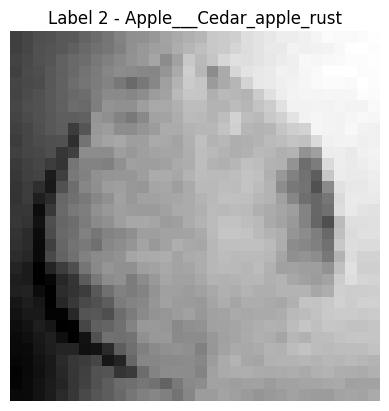

In [12]:
def show_example(x_vec, label_idx, img_size=IMG_SIZE):
    """
    Show one example image from flattened vector.
    """
    img_array = np.array(x_vec).reshape(img_size, img_size)
    plt.imshow(img_array, cmap="gray")
    plt.title(f"Label {label_idx} - {idx_to_class[label_idx]}")
    plt.axis("off")
    plt.show()

# Show one random train example
rand_idx = random.randint(0, len(X_train) - 1)
show_example(X_train[rand_idx], y_train[rand_idx])

Bu hücre:

* Flatten vektörden (`[0..1]` aralığında 1024 değer) tekrar `32x32` görüntü oluşturuyor.

* Matplotlib ile gösterip doğru sınıfa benziyor mu test etmeni sağlıyor.

* Böylece preprocessing'in doğru çalıştığını gözle kontrol edebilirsin.

## Cell 10 – (Opsiyonel) Numpy array olarak kaydetme

In [13]:
SAVE_DIR = "preprocessed_plantvillage"
os.makedirs(SAVE_DIR, exist_ok=True)

def save_split(X_split, y_split, name_prefix):
    X_array = np.array(X_split, dtype=np.float32)
    y_array = np.array(y_split, dtype=np.int64)
    np.save(os.path.join(SAVE_DIR, f"{name_prefix}_X.npy"), X_array)
    np.save(os.path.join(SAVE_DIR, f"{name_prefix}_y.npy"), y_array)
    print(f"Saved {name_prefix}_X.npy and {name_prefix}_y.npy")

save_split(X_train, y_train, "train")
save_split(X_val, y_val, "val")
save_split(X_test, y_test, "test")

Saved train_X.npy and train_y.npy
Saved val_X.npy and val_y.npy
Saved test_X.npy and test_y.npy


Bu hücre:

* İşlenmiş veriyi `preprocessed_plantvillage/` klasörüne `.npy` dosyaları olarak kaydediyor.

* Sonra Logistic Regression, SVM, Random Forest gibi modelleri denerken:

  * Notebook'un başka bir yerinde sadece bu `.npy` dosyalarını yükleyip modeli çalıştırabilirsin; preprocessing adımlarını her seferinde yapmak zorunda kalmazsın.